# Notebook 03 — Degree Analysis

This notebook focuses only on degree-based analysis of the `cit-HepTh` citation network.

The goal is to compute and visualize:

- in-degree;
- out-degree;
- total degree;
- top papers by degree;
- empirical degree distributions;
- log-log degree distribution plots;
- complementary cumulative distribution functions (CCDFs).

In this directed citation network:

- `from_node_id` is the paper that cites another paper;
- `to_node_id` is the paper being cited;
- `in_degree` is the number of citations received by a paper;
- `out_degree` is the number of papers cited by a paper.

## 1. Imports and project paths

The notebook is expected to be located inside the `notebooks/` folder.

The following path logic makes the notebook work both when it is executed from the project root and when it is executed from the `notebooks/` folder.

In [27]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
DEGREE_OUTPUT_DIR = OUTPUT_DIR / "degree_analysis"
FIGURES_DIR = DEGREE_OUTPUT_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
DEGREE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_EDGES_PATH = PROCESSED_DIR / "cit_hepth_clean_edges.parquet"
NODE_DEGREES_PATH = PROCESSED_DIR / "cit_hepth_node_degrees.parquet"

print(f"Current working directory: {CURRENT_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Clean edges path: {CLEAN_EDGES_PATH}")
print(f"Clean edges file exists: {CLEAN_EDGES_PATH.exists()}")

Current working directory: /Users/chiarabelli/Desktop/citation-network-project/notebooks
Project root: /Users/chiarabelli/Desktop/citation-network-project
Clean edges path: /Users/chiarabelli/Desktop/citation-network-project/data/processed/cit_hepth_clean_edges.parquet
Clean edges file exists: True


## 2. Initialize Spark session

Spark is used to load the cleaned edge list and compute degree counts through distributed group-by operations.

In [28]:
spark = (
    SparkSession.builder
    .appName("CitHepThDegreeAnalysis")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

ConnectionRefusedError: [Errno 61] Connection refused

## 3. Load the cleaned edge list

This notebook starts from the cleaned edge list created in Notebook 01.

Expected input:

```text
data/processed/cit_hepth_clean_edges.parquet
```

Expected columns:

```text
from_node_id
to_node_id
```

In [3]:
if not CLEAN_EDGES_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned edge list not found at: {CLEAN_EDGES_PATH}\n"
        "Please run Notebook 01 first."
    )

edges_sdf = spark.read.parquet(str(CLEAN_EDGES_PATH))

edges_sdf.printSchema()
edges_sdf.show(5)

root
 |-- from_node_id: long (nullable = true)
 |-- to_node_id: long (nullable = true)

+------------+----------+
|from_node_id|to_node_id|
+------------+----------+
|        1001|   9503124|
|        1001|   9505162|
|        1001|   9510225|
|        1001|   9511171|
|        1001|   9602114|
+------------+----------+
only showing top 5 rows


## 4. Build the node table

The edge list contains only citation relations. To compute degrees correctly, we first build the full set of nodes appearing either as citing papers or cited papers.

In [5]:
from_nodes_sdf = edges_sdf.select(F.col("from_node_id").alias("node_id"))
to_nodes_sdf = edges_sdf.select(F.col("to_node_id").alias("node_id"))

nodes_sdf = from_nodes_sdf.union(to_nodes_sdf).distinct()

num_nodes = nodes_sdf.count()
num_edges = edges_sdf.count()

summary_df = pd.DataFrame(
    {
        "Metric": ["Number of nodes", "Number of directed edges"],
        "Value": [num_nodes, num_edges],
    }
)

display(
    summary_df.style
    .hide(axis="index")
    .format({"Value": "{:,}"})
)

Metric,Value
Number of nodes,"27,769"
Number of directed edges,"352,768"


## 5. Compute in-degree

The in-degree of a paper is the number of incoming citation edges.

In this dataset, an edge:

```text
from_node_id -> to_node_id
```

means that `from_node_id` cites `to_node_id`.

Therefore, the in-degree of a node is obtained by counting how many times it appears as `to_node_id`.

In [6]:
in_degree_sdf = (
    edges_sdf
    .groupBy("to_node_id")
    .agg(F.count("*").alias("in_degree"))
    .withColumnRenamed("to_node_id", "node_id")
)

top_in_degree_pdf = (
    in_degree_sdf
    .orderBy(F.desc("in_degree"), F.asc("node_id"))
    .limit(20)
    .toPandas()
)

display(
    top_in_degree_pdf.style
    .hide(axis="index")
    .format({"node_id": "{:,}", "in_degree": "{:,}"})
    .set_caption("Top 20 papers by in-degree")
)

node_id,in_degree
"9,711,200","2,414"
"9,802,150","1,775"
"9,802,109","1,641"
"9,407,087","1,299"
"9,610,043","1,199"
"9,510,017","1,155"
"9,908,142","1,144"
"9,503,124","1,114"
"9,906,064","1,032"
"9,408,099","1,006"


## 7. Compute out-degree

The out-degree of a paper is the number of outgoing citation edges.

In this dataset, the out-degree of a node is obtained by counting how many times it appears as `from_node_id`.

In [7]:
out_degree_sdf = (
    edges_sdf
    .groupBy("from_node_id")
    .agg(F.count("*").alias("out_degree"))
    .withColumnRenamed("from_node_id", "node_id")
)

top_out_degree_pdf = (
    out_degree_sdf
    .orderBy(F.desc("out_degree"), F.asc("node_id"))
    .limit(20)
    .toPandas()
)

display(
    top_out_degree_pdf.style
    .hide(axis="index")
    .format({"node_id": "{:,}", "out_degree": "{:,}"})
    .set_caption("Top 20 papers by out-degree")
)

node_id,out_degree
"9,905,111",562
"9,710,046",359
"110,055",302
"210,157",289
"101,126",274
"7,170",263
"204,089",246
"201,253",226
"9,809,039",216
"9,802,067",214


## 8. Build the final degree table

Some papers may have zero in-degree or zero out-degree.

For this reason, the degree tables are left-joined to the complete node table and missing values are replaced with zero.

In [26]:
node_degrees_with_nulls_sdf = (
    nodes_sdf
    .join(in_degree_sdf, on="node_id", how="left")
    .join(out_degree_sdf, on="node_id", how="left")
)

missing_degree_summary_sdf = node_degrees_with_nulls_sdf.select(
    F.count("*").alias("total_nodes"),
    F.sum(F.when(F.col("in_degree").isNull(), 1).otherwise(0)).alias("missing_in_degree"),
    F.sum(F.when(F.col("out_degree").isNull(), 1).otherwise(0)).alias("missing_out_degree"),
    F.sum(
        F.when(
            F.col("in_degree").isNull() & F.col("out_degree").isNull(),
            1
        ).otherwise(0)
    ).alias("missing_both")
)

missing_degree_summary_pdf = missing_degree_summary_sdf.toPandas()

display(
    missing_degree_summary_pdf.style
    .hide(axis="index")
    .format("{:,}")
)

node_degrees_sdf = (
    node_degrees_with_nulls_sdf
    .fillna(0, subset=["in_degree", "out_degree"])
    .withColumn("total_degree", F.col("in_degree") + F.col("out_degree"))
)

ConnectionRefusedError: [Errno 61] Connection refused

In [ ]:
zero_degree_summary_sdf = node_degrees_sdf.select(
    F.count("*").alias("total_nodes"),
    F.sum(F.when(F.col("in_degree") == 0, 1).otherwise(0)).alias("zero_in_degree"),
    F.sum(F.when(F.col("out_degree") == 0, 1).otherwise(0)).alias("zero_out_degree"),
    F.sum(
        F.when(
            (F.col("in_degree") == 0) & (F.col("out_degree") == 0),
            1
        ).otherwise(0)
    ).alias("zero_both")
)

zero_degree_summary_pdf = zero_degree_summary_sdf.toPandas()

display(
    zero_degree_summary_pdf.style
    .hide(axis="index")
    .format("{:,}")
)

In [12]:
top_total_degree_pdf = (
    node_degrees_sdf
    .orderBy(F.desc("total_degree"), F.asc("node_id"))
    .limit(20)
    .toPandas()
)

display(
    top_total_degree_pdf
    .style
    .hide(axis="index")
    .format({
        "node_id": "{}",
        "in_degree": "{:,}",
        "out_degree": "{:,}",
        "total_degree": "{:,}",
    })
    .background_gradient(subset=["total_degree"])
    .set_caption("Top 20 papers by total degree")
)

node_id,in_degree,out_degree,total_degree
9711200,"2,414",54,"2,468"
9802150,"1,775",22,"1,797"
9802109,"1,641",12,"1,653"
9905111,807,562,"1,369"
9407087,"1,299",9,"1,308"
9908142,"1,144",75,"1,219"
9610043,"1,199",19,"1,218"
9510017,"1,155",10,"1,165"
9503124,"1,114",10,"1,124"
9906064,"1,032",6,"1,038"


## 9. Degree summary statistics

This table gives a compact numerical summary of in-degree, out-degree and total degree.

In [10]:
degree_summary_pdf = (
    node_degrees_sdf
    .select("in_degree", "out_degree", "total_degree")
    .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")
    .toPandas()
)

display(
    degree_summary_pdf.style
    .hide(axis="index")
    .set_caption("Degree summary statistics")
)

summary,in_degree,out_degree,total_degree
count,27769,27769,27769
mean,12.703662357304909,12.703662357304909,25.407324714609818
stddev,39.816997302457274,15.966405911939717,45.34007266443354
min,0,0,1
25%,1,2,6
50%,4,8,14
75%,12,18,31
max,2414,562,2468


## 10. Save degree tables

The final node-level degree table is saved as Parquet and CSV.

The Parquet file will be reused in later notebooks.

In [11]:
node_degrees_sdf.write.mode("overwrite").parquet(str(NODE_DEGREES_PATH))

node_degrees_pdf_for_export = node_degrees_sdf.orderBy("node_id").toPandas()
node_degrees_pdf_for_export.to_csv(
    DEGREE_OUTPUT_DIR / "cit_hepth_node_degrees.csv",
    index=False
)

top_in_degree_pdf.to_csv(DEGREE_OUTPUT_DIR / "top_20_in_degree.csv", index=False)
top_out_degree_pdf.to_csv(DEGREE_OUTPUT_DIR / "top_20_out_degree.csv", index=False)
top_total_degree_pdf.to_csv(DEGREE_OUTPUT_DIR / "top_20_total_degree.csv", index=False)

print(f"Saved Parquet degree table to: {NODE_DEGREES_PATH}")
print(f"Saved CSV outputs to: {DEGREE_OUTPUT_DIR}")

26/05/15 13:01:39 WARN MemoryManager: Total allocation exceeds 95,00% (1.020.054.720 bytes) of heap memory
Scaling row group sizes to 95,00% for 8 writers


Saved Parquet degree table to: /Users/chiarabelli/Desktop/citation-network-project/data/processed/cit_hepth_node_degrees.parquet
Saved CSV outputs to: /Users/chiarabelli/Desktop/citation-network-project/outputs/degree_analysis


## 11. Prepare data for plotting

The graph contains around 27k nodes, so converting the node-level degree table to pandas is safe for plotting.

To make this section robust, the degree table is reloaded from the saved Parquet file instead of relying on a variable created in previous cells.

In [13]:
if not NODE_DEGREES_PATH.exists():
    raise FileNotFoundError(
        f"Node degree table not found at: {NODE_DEGREES_PATH}\n"
        "Please run the previous cells that compute and save the node degree table first."
    )

node_degrees_sdf = spark.read.parquet(str(NODE_DEGREES_PATH))
degrees_pdf = node_degrees_sdf.toPandas()

print(degrees_pdf.shape)
degrees_pdf.head()

(27769, 4)


,node_id,in_degree,out_degree,total_degree
0,9505025,30,14,44
1,9506112,189,17,206
2,9508094,90,29,119
3,9508155,192,53,245
4,9511030,329,21,350


## 12. Histograms of in-degree and out-degree

The standard histograms show the raw distribution of degree values.

In citation networks, these distributions are usually highly skewed: most papers have low degree, while a small number of papers have very high degree.

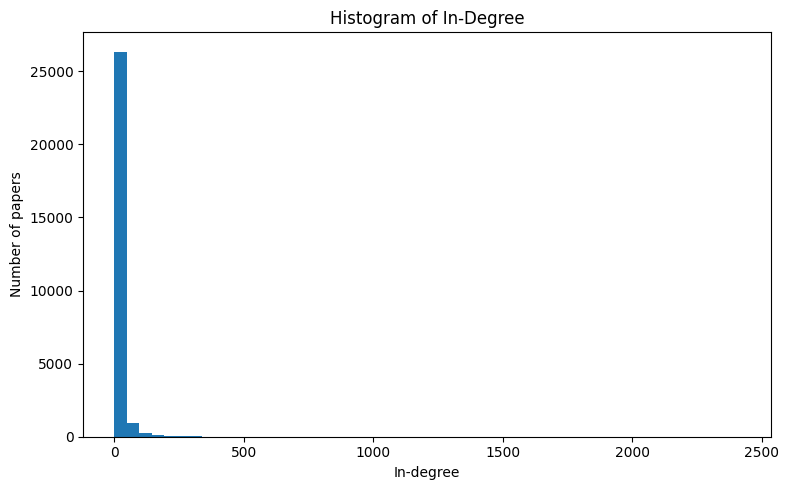

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(degrees_pdf["in_degree"], bins=50)
plt.xlabel("In-degree")
plt.ylabel("Number of papers")
plt.title("Histogram of In-Degree")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "histogram_in_degree.png", dpi=300)
plt.show()

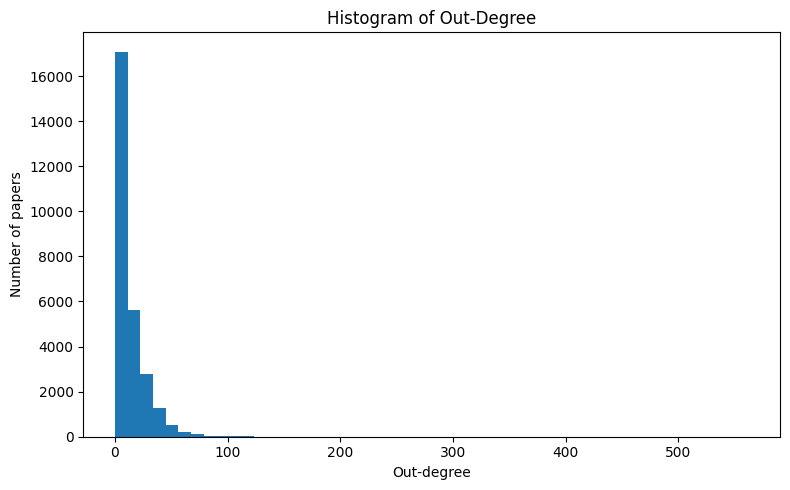

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(degrees_pdf["out_degree"], bins=50)
plt.xlabel("Out-degree")
plt.ylabel("Number of papers")
plt.title("Histogram of Out-Degree")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "histogram_out_degree.png", dpi=300)
plt.show()

## 13. Empirical degree distributions

The empirical degree distribution is:

$$
P(k) = \frac{\text{number of nodes with degree } k}{\text{total number of nodes}}
$$

This is computed separately for in-degree and out-degree.

In [16]:
def compute_degree_distribution(degree_values):
    """
    Compute the empirical degree distribution P(k).

    Parameters
    ----------
    degree_values : array-like
        Sequence of degree values.

    Returns
    -------
    pandas.DataFrame
        DataFrame with columns:
        - degree;
        - count;
        - probability.
    """
    degree_values = np.asarray(degree_values)

    unique_degrees, counts = np.unique(degree_values, return_counts=True)
    probabilities = counts / counts.sum()

    distribution_df = pd.DataFrame(
        {
            "degree": unique_degrees,
            "count": counts,
            "probability": probabilities,
        }
    )

    return distribution_df


in_degree_distribution = compute_degree_distribution(degrees_pdf["in_degree"])
out_degree_distribution = compute_degree_distribution(degrees_pdf["out_degree"])

in_degree_distribution.to_csv(
    DEGREE_OUTPUT_DIR / "in_degree_distribution.csv",
    index=False
)

out_degree_distribution.to_csv(
    DEGREE_OUTPUT_DIR / "out_degree_distribution.csv",
    index=False
)

display(
    in_degree_distribution.head(10).style
    .hide(axis="index")
    .format({"degree": "{:,}", "count": "{:,}", "probability": "{:.6f}"})
    .set_caption("In-degree distribution")
)

display(
    out_degree_distribution.head(10).style
    .hide(axis="index")
    .format({"degree": "{:,}", "count": "{:,}", "probability": "{:.6f}"})
    .set_caption("Out-degree distribution")
)

degree,count,probability
0,"4,593",0.165400
1,"3,787",0.136375
2,"2,699",0.097195
3,"1,994",0.071807
4,"1,638",0.058987
5,"1,327",0.047787
6,"1,138",0.040981
7,901,0.032446
8,824,0.029673
9,690,0.024848


degree,count,probability
0,"2,714",0.097735
1,"2,445",0.088048
2,"1,953",0.070330
3,"1,657",0.059671
4,"1,403",0.050524
5,"1,274",0.045878
6,"1,170",0.042133
7,"1,091",0.039288
8,971,0.034967
9,849,0.030574


## 14. Log-log degree distribution plots

Log-log plots make the tail of the distribution easier to inspect.

They are useful for checking whether the network appears heavy-tailed.

At this stage, we only visually inspect the distributions. We do not claim that they follow a power law without a formal statistical fitting procedure.

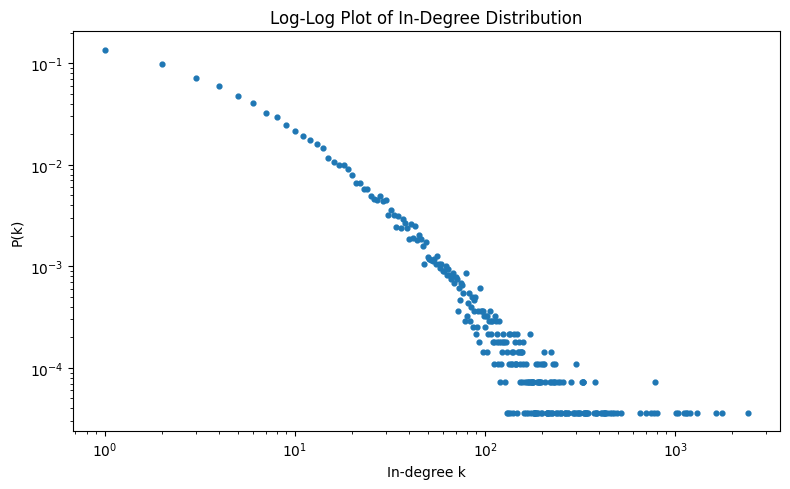

In [17]:
in_degree_distribution_nonzero = in_degree_distribution[
    in_degree_distribution["degree"] > 0
]

plt.figure(figsize=(8, 5))
plt.scatter(
    in_degree_distribution_nonzero["degree"],
    in_degree_distribution_nonzero["probability"],
    s=12
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("In-degree k")
plt.ylabel("P(k)")
plt.title("Log-Log Plot of In-Degree Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "loglog_in_degree_distribution.png", dpi=300)
plt.show()

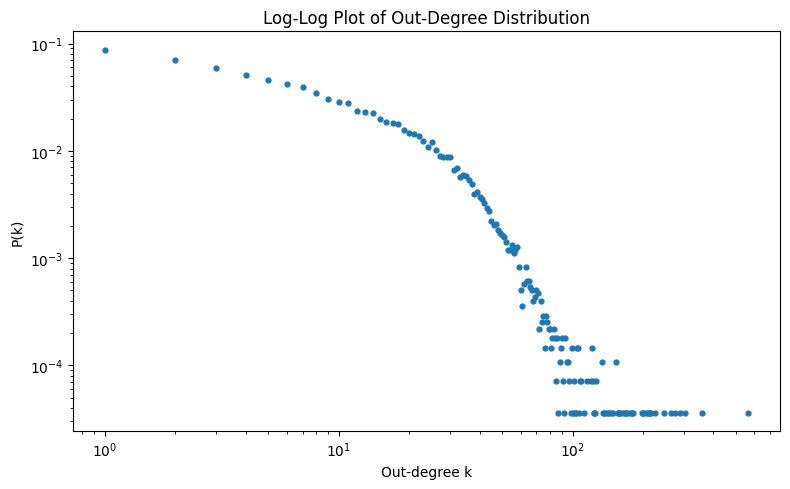

In [18]:
out_degree_distribution_nonzero = out_degree_distribution[
    out_degree_distribution["degree"] > 0
]

plt.figure(figsize=(8, 5))
plt.scatter(
    out_degree_distribution_nonzero["degree"],
    out_degree_distribution_nonzero["probability"],
    s=12
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Out-degree k")
plt.ylabel("P(k)")
plt.title("Log-Log Plot of Out-Degree Distribution")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "loglog_out_degree_distribution.png", dpi=300)
plt.show()

## 15. Complementary Cumulative Distribution Function

The complementary cumulative distribution function, or CCDF, is defined as:

$$
P(K \geq k)
$$

It measures the probability that a randomly selected node has degree at least equal to \(k\).

In this project:

- the in-degree CCDF shows the fraction of papers receiving at least \(k\) citations;
- the out-degree CCDF shows the fraction of papers citing at least \(k\) other papers.

In [19]:
def compute_ccdf(degree_values):
    """
    Compute the complementary cumulative distribution function P(K >= k).

    Parameters
    ----------
    degree_values : array-like
        Sequence of degree values.

    Returns
    -------
    pandas.DataFrame
        DataFrame with columns:
        - degree;
        - ccdf.
    """
    degree_values = np.asarray(degree_values)

    unique_degrees = np.sort(np.unique(degree_values))
    total_nodes = len(degree_values)

    ccdf_values = np.array([
        np.sum(degree_values >= k) / total_nodes
        for k in unique_degrees
    ])

    ccdf_df = pd.DataFrame(
        {
            "degree": unique_degrees,
            "ccdf": ccdf_values,
        }
    )

    return ccdf_df


in_degree_ccdf = compute_ccdf(degrees_pdf["in_degree"])
out_degree_ccdf = compute_ccdf(degrees_pdf["out_degree"])

in_degree_ccdf.to_csv(DEGREE_OUTPUT_DIR / "in_degree_ccdf.csv", index=False)
out_degree_ccdf.to_csv(DEGREE_OUTPUT_DIR / "out_degree_ccdf.csv", index=False)

display(
    in_degree_ccdf.head(10).style
    .hide(axis="index")
    .format({"degree": "{:,}", "ccdf": "{:.6f}"})
    .set_caption("In-degree CCDF")
)

display(
    out_degree_ccdf.head(10).style
    .hide(axis="index")
    .format({"degree": "{:,}", "ccdf": "{:.6f}"})
    .set_caption("Out-degree CCDF")
)

degree,ccdf
0,1.000000
1,0.834600
2,0.698225
3,0.601030
4,0.529223
5,0.470237
6,0.422449
7,0.381469
8,0.349022
9,0.319349


degree,ccdf
0,1.000000
1,0.902265
2,0.814217
3,0.743887
4,0.684216
5,0.633692
6,0.587814
7,0.545680
8,0.506392
9,0.471425


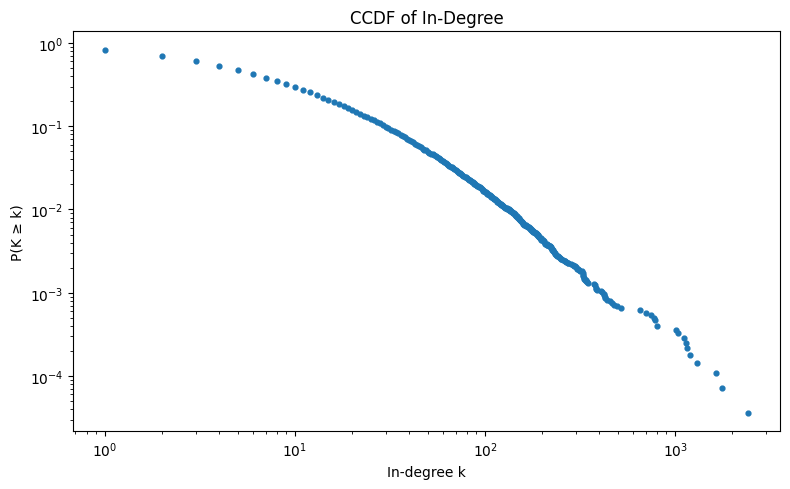

In [20]:
in_degree_ccdf_nonzero = in_degree_ccdf[in_degree_ccdf["degree"] > 0]

plt.figure(figsize=(8, 5))
plt.scatter(
    in_degree_ccdf_nonzero["degree"],
    in_degree_ccdf_nonzero["ccdf"],
    s=12
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("In-degree k")
plt.ylabel("P(K ≥ k)")
plt.title("CCDF of In-Degree")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ccdf_in_degree.png", dpi=300)
plt.show()

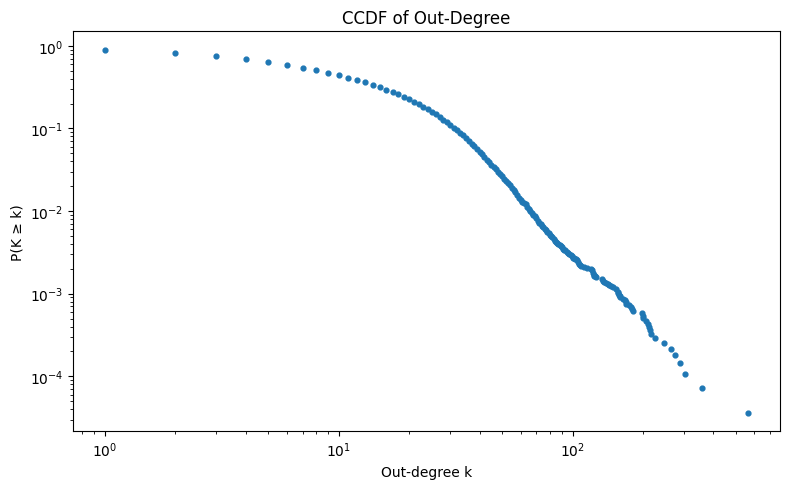

In [21]:
out_degree_ccdf_nonzero = out_degree_ccdf[out_degree_ccdf["degree"] > 0]

plt.figure(figsize=(8, 5))
plt.scatter(
    out_degree_ccdf_nonzero["degree"],
    out_degree_ccdf_nonzero["ccdf"],
    s=12
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Out-degree k")
plt.ylabel("P(K ≥ k)")
plt.title("CCDF of Out-Degree")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ccdf_out_degree.png", dpi=300)
plt.show()